In [1]:
# Locate fix_notebook_dir.py whether the kernel started in this folder or in the
# repository root, then let it put pyncd on the import path. See fix_notebook_dir.py.
import sys; sys.path[:0] = ['.', 'example_notebooks']
import fix_notebook_dir

In [2]:
import construction_helpers as ch # Needed for @ auto-alignment
import data_structure.Operators as ops
import websocket_transfer.capture as cap

Requesting render from server...
Received from server: {"msgType": "Connected"}


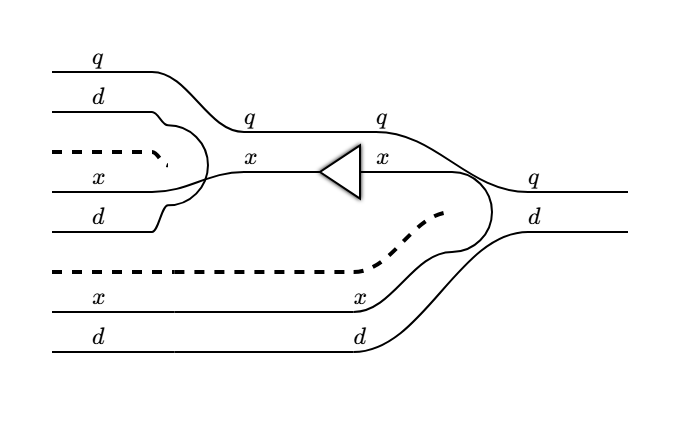

In [3]:
''' Attention '''
qk_matmul = ops.Einops.template('q d, x d -> q x')
softmax = ops.SoftMax.template()
sv_matmul = ops.Einops.template('q x, x d -> q d')
attention = qk_matmul @ softmax @ sv_matmul
await cap.capture_morphism(attention)

Name|Type       |Bucket  |Assignment
d   |FreeNumeric|        |          
q   |FreeNumeric|        |          
x   |FreeNumeric|        |          
d   |FreeNumeric|        |          
Name|Type       |Bucket  |Assignment         
d   |FreeNumeric|0       |Integer(_value=128)
q   |FreeNumeric|        |                   
x   |FreeNumeric|        |                   
d   |FreeNumeric|0       |Integer(_value=128)
Name|Type       |Bucket  |Assignment
q   |FreeNumeric|        |          
x   |FreeNumeric|        |          
Requesting render from server...
Received from server: {"msgType": "Connected"}


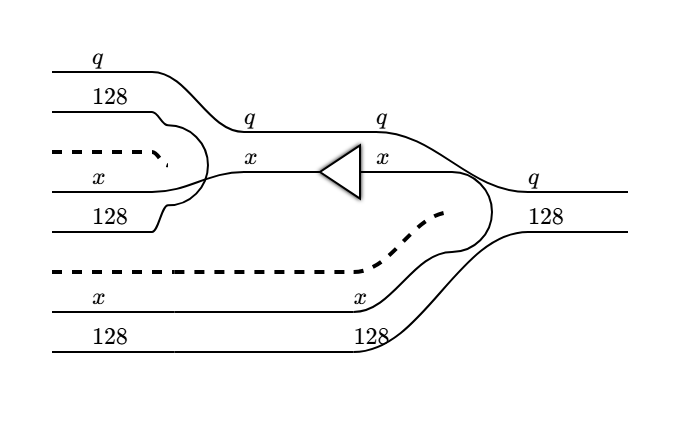

In [4]:
import term_utilities.generate_config as gc
import data_structure.Numeric as nm
import display.display_config as dpc

# We create a config log attached to ``attention``
config_log = gc.NumericConfig.template(attention)
# This assembles the free numeric variables
print(dpc.display_config(config_log))

# We can assign a value, which is reflected in the ``imposed_context``.
# This can now be used to assign the values within the expression.
config_log.assign_value('d', 128)
print(dpc.display_config(config_log))
attention_128 = config_log.apply_context(attention)

# A new config will no longer see the d values as being FreeNumerics
config_log_new = gc.NumericConfig.template(attention_128)
print(dpc.display_config(config_log_new))


await cap.capture_morphism(attention_128)